In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg

from multipred.plotting import barplot_morey, analyze_attention_ROI, plot_decoding_nvoxels

In [3]:
PROJECT_PATH = "/media/wiseman/tocho/predrelv_fmri/"
DATA_PATH = f"{PROJECT_PATH}/group_analyses/multivariate/MVPA_proba/analyses/decoding_data/"
ROI = "earlyvisual"

## Comparing decoding across ROI sizes

24 subjects in 50 voxels mask. t(23)=4.1685, p=0.0001. Auditory modality: t(23)=1.8956, p=0.0642
23 subjects in 100 voxels mask. t(22)=5.2168, p=0.0000. Auditory modality: t(22)=3.7823, p=0.0005
23 subjects in 150 voxels mask. t(22)=6.3296, p=0.0000. Auditory modality: t(22)=3.8431, p=0.0004
23 subjects in 200 voxels mask. t(22)=6.4368, p=0.0000. Auditory modality: t(22)=5.1757, p=0.0000
23 subjects in 250 voxels mask. t(22)=7.1095, p=0.0000. Auditory modality: t(22)=5.3672, p=0.0000
23 subjects in 300 voxels mask. t(22)=7.8893, p=0.0000. Auditory modality: t(22)=5.3781, p=0.0000
23 subjects in 350 voxels mask. t(22)=7.6574, p=0.0000. Auditory modality: t(22)=4.7008, p=0.0000
25 subjects in funcloc voxels mask. t(24)=6.3015, p=0.0000. Auditory modality: t(24)=5.5070, p=0.0000
25 subjects in wholeROI voxels mask. t(24)=5.7348, p=0.0000. Auditory modality: t(24)=3.9183, p=0.0003


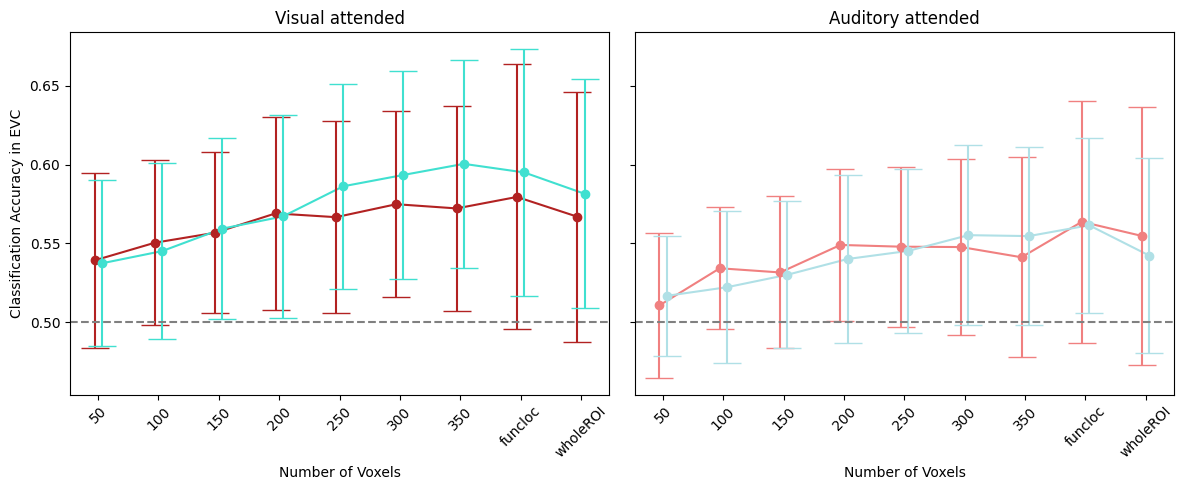

In [4]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "350",
    "funcloc",
    "wholeROI",
]
df_allROIs = plot_decoding_nvoxels(DATA_PATH, n_voxels_list, ROI, "v_pred")

## Analyze specific ROIs

In [14]:
ROI = "earlyvisual"
n_voxels = "funcloc"
df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")
df_grouped = df.groupby(["subj", "modality", "a_pred", "v_pred"], as_index=False)[
    "correct"
].mean()

### Attention * visual prediction

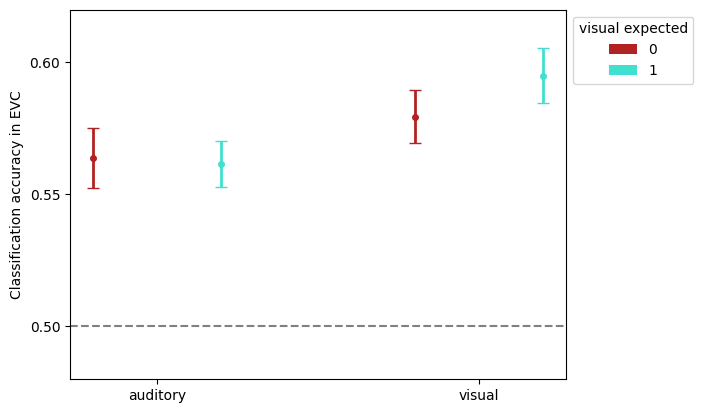

In [15]:
y = "correct"
x = "modality"
hue = "v_pred"
id = "subj"
dat = df.copy().groupby([id, x, hue], as_index=False)[y].mean()
barplot_morey(dat, x, y, hue, "visual expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], False, False, False)
plt.xticks([0, 1], ["auditory", "visual"])
plt.ylabel(f"Classification accuracy in EVC")
plt.ylim(0.48, 0.62)
plt.yticks([0.5, 0.55, 0.6])
plt.axhline(0.5, color="grey", linestyle="--")

In [16]:
pg.rm_anova(dv=y, within=[x, hue], subject=id, data=dat.copy())

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,modality,0.015211,1,24,0.015211,4.349805,0.047819,0.047819,0.019052,1.0
1,v_pred,0.001117,1,24,0.001117,0.376993,0.544994,0.544994,0.001424,1.0
2,modality * v_pred,0.001973,1,24,0.001973,1.458630,0.238916,0.238916,0.002513,1.0


In [17]:
pg.pairwise_tests(dv=y, within=[x, hue], subject=id, data=dat, padjust="fdr_bh")

,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,-2.085619,24.0,two-sided,0.047819,NaN,NaN,1.327,-0.288557
1,v_pred,-,0,1,True,True,-0.613998,24.0,two-sided,0.544994,NaN,NaN,0.25,-0.078932
2,modality * v_pred,auditory,0,1,True,True,0.168345,24.0,two-sided,0.867722,0.867722,fdr_bh,0.214,0.026670
3,modality * v_pred,visual,0,1,True,True,-1.178806,24.0,two-sided,0.250031,0.500061,fdr_bh,0.392,-0.155380


### Multimodal analyses

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean

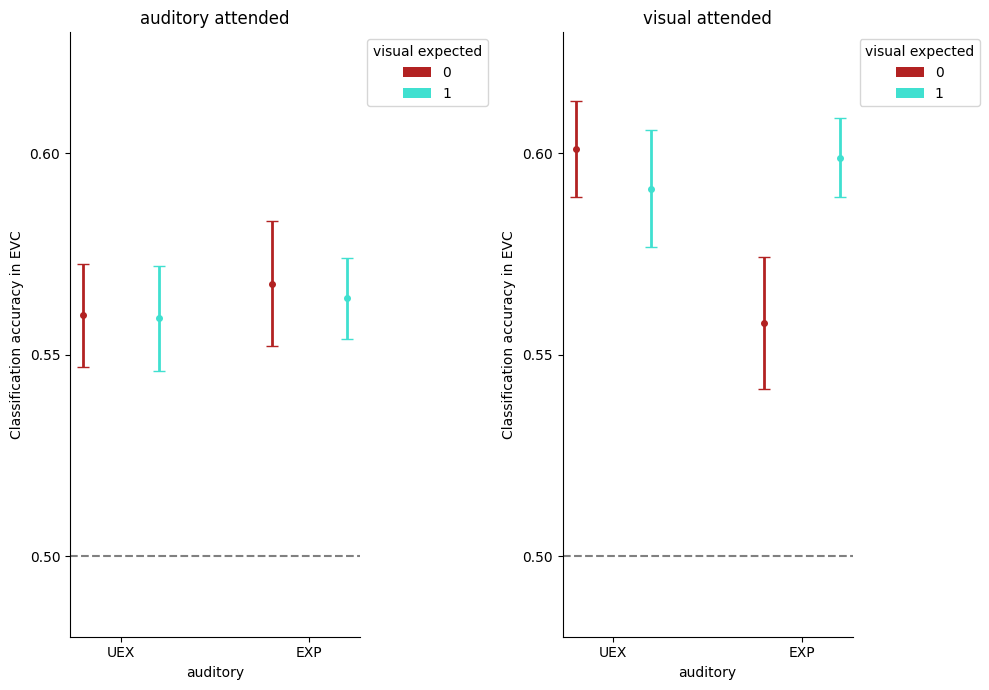

In [18]:
y = "correct"
x = "a_pred"
hue = "v_pred"
id = "subj"
ROI = "EVC"
save_fig = False
ylim = (0.48, 0.63)
yticks = [0.5, 0.55, 0.6]

anova_df, posthoc_df = analyze_attention_ROI(
    df_grouped, y, x, hue, "visual expected", id, ROI, save_fig, ylim, yticks
)

In [19]:
anova_df

,level_0,level_1,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,auditory attended,0,a_pred,0.001019,1,24,0.001019,0.207370,0.652930,0.652930,0.001221,1.0
1,auditory attended,1,v_pred,0.000121,1,24,0.000121,0.028340,0.867722,0.867722,0.000145,1.0
2,auditory attended,2,a_pred * v_pred,0.000051,1,24,0.000051,0.014893,0.903885,0.903885,0.000062,1.0
3,visual attended,0,a_pred,0.007921,1,24,0.007921,1.839311,0.187655,0.187655,0.006849,1.0
4,visual attended,1,v_pred,0.006058,1,24,0.006058,1.389584,0.250031,0.250031,0.005246,1.0
5,visual attended,2,a_pred * v_pred,0.016193,1,24,0.016193,3.476923,0.074506,0.074506,0.013901,1.0


In [20]:
posthoc_df

,level_0,level_1,Contrast,a_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,auditory attended,0,a_pred,-,0,1,True,True,-0.455378,24.0,two-sided,0.652930,NaN,NaN,0.232,-0.076458
1,auditory attended,1,v_pred,-,0,1,True,True,0.168345,24.0,two-sided,0.867722,NaN,NaN,0.214,0.026670
2,auditory attended,2,a_pred * v_pred,0,0,1,True,True,0.044023,24.0,two-sided,0.965250,0.965250,fdr_bh,0.211,0.007710
3,auditory attended,3,a_pred * v_pred,1,0,1,True,True,0.204985,24.0,two-sided,0.839312,0.965250,fdr_bh,0.215,0.040529
4,visual attended,0,a_pred,-,0,1,True,True,1.356212,24.0,two-sided,0.187655,NaN,NaN,0.476,0.177794
5,visual attended,1,v_pred,-,0,1,True,True,-1.178806,24.0,two-sided,0.250031,NaN,NaN,0.392,-0.155380
6,visual attended,2,a_pred * v_pred,0,0,1,True,True,0.527699,24.0,two-sided,0.602553,0.602553,fdr_bh,0.239,0.086881
7,visual attended,3,a_pred * v_pred,1,0,1,True,True,-2.130742,24.0,two-sided,0.043557,0.087113,fdr_bh,1.429,-0.378246
